In [6]:
import numpy as np
import pandas as pd
import folium
import ipywidgets as widgets 
from IPython.display import display, HTML
#from otter import Notebook
from datascience import *
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')
plt.rcParams["patch.force_edgecolor"] = True
import seaborn as sns
print('Done!')

Done!


## Orange Sky Over the Bay Area Exploratory Data Analysis

On Wednesday, September 9th, 2020, Bay Area residents woke up to an orange sky and general haze that lasted throughout the day. These conditions were caused by record-setting wildfires burning across California, Colorado, Oregon and Washington state. The fires resulted in thick particle clouds that scattered blue wavelengths of light and left only reds and yellows, creating this odd red haze.

While visibility was affected on September 9th, it wasn't until the following day (Thursday, September 10th) that the air quality (as measured by Aerosol concentration) became dramatically worse, a trend that continued for over a week afterward. This poor air quality was recorded by several nodes in the BEACO2N network, including the one located on the Exploratorium Bay, as well as Dan Mini Elementary School and College Preparatory School.

http://beacon.berkeley.edu/events/orange-sky-over-bay-area-992020/

#### Reading in the Data
We will be taking a look at emission levels for the month prior to the orange sky versus during the orange sky period over the Bay Area (high carbon concentration).

In [20]:
orange_sky_emission_levels = Table.read_table('Exploratorium Bay_start_2020-09-09 00_00_00_end_2020-09-30 16_00_00_measurements.csv')
orange_sky_emission_levels.show(4)

local_timestamp,datetime,node_id,epoch,julian_day,co_ppm,co_ppm_QC_level,co2_ppm,co2_ppm_QC_level,o3_ppm,o3_ppm_QC_level,PM_2.5_ug/m3,PM_2.5_ug/m3_QC_level
2020-09-09 00:00:00,2020-09-09 07:00:00,48,1.59963e+09,253.292,0.16,2,413.4,2,0.1096,nan,-999,nan
2020-09-09 01:00:00,2020-09-09 08:00:00,48,1.59964e+09,253.333,0.17,2,414.6,2,0.1261,nan,-999,nan
2020-09-09 02:00:00,2020-09-09 09:00:00,48,1.59964e+09,253.375,0.17,2,413,2,0.1339,nan,-999,nan
2020-09-09 03:00:00,2020-09-09 10:00:00,48,1.59965e+09,253.417,0.16,2,414.1,2,0.1244,nan,-999,nan


In [22]:
prev_month_emission_levels = Table.read_table('Exploratorium Bay_start_2020-08-09 00_00_00_end_2020-09-04 16_00_00_measurements.csv')
prev_month_emission_levels.show(4)

local_timestamp,datetime,node_id,epoch,julian_day,co_ppm,co_ppm_QC_level,co2_ppm,co2_ppm_QC_level,o3_ppm,o3_ppm_QC_level,PM_2.5_ug/m3,PM_2.5_ug/m3_QC_level
2020-08-09 00:00:00,2020-08-09 07:00:00,48,1.59696e+09,222.292,0.1,2,407.1,2,0.2002,nan,-999,nan
2020-08-09 01:00:00,2020-08-09 08:00:00,48,1.59696e+09,222.333,0.09,2,407.1,2,0.1966,nan,-999,nan
2020-08-09 02:00:00,2020-08-09 09:00:00,48,1.59696e+09,222.375,0.09,2,406.8,2,0.2006,nan,-999,nan
2020-08-09 03:00:00,2020-08-09 10:00:00,48,1.59697e+09,222.417,0.08,2,407.1,2,0.1907,nan,-999,nan


#### Take a look at the upper range of values for CO2 during the orange sky
We can take a look by sorting co2_ppm (the 7th column) in descending order (from greatest CO2 concentration to least concentration)

In [23]:
orange_sky_emission_levels.sort(7, descending=True).select(7).show(5)

co2_ppm
491.1
481.6
478.1
471.9
466.9


In [24]:
orange_sky_emission_levels.sort(7, descending=False).select(7).show(5)
#Here are the lowest CO2 concentration levels recorded during the month of orange skys 

co2_ppm
407.1
407.1
407.2
407.8
407.9


#### Compare CO2 levels with emission data from the previous month
Take a look at the difference in concentration by comparing high and low CO2 concetrations from the previous month 

In [26]:
prev_month_emission_levels.sort(7, descending=True).select(7).show(5)

co2_ppm
442.8
438.9
438.6
435.2
433.2


In [27]:
prev_month_emission_levels.sort(7, descending=False).select(7).show(5)

co2_ppm
400.2
400.4
400.5
400.6
400.8


### What differences do you see in the ranges of Carbon Dioxide concentrations after comparing both time frames?

## Let's take a look at their line plots

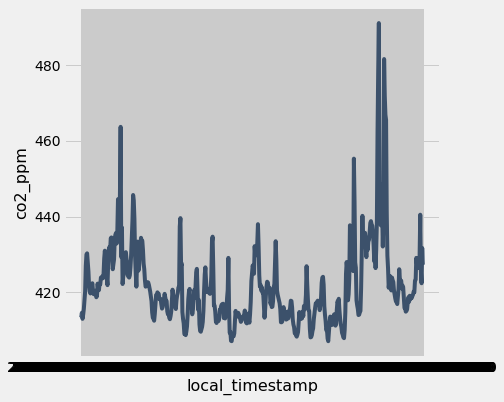

In [38]:
orange_sky_emission_levels.plot('local_timestamp', 'co2_ppm')
#orange_sky_emission_levels.ylim([400, 500])
#can't find data science parameter to create ylim to have the same ylim for both previous month and month of orange sky
#http://www.data8.org/datascience/reference-nb/datascience-reference.html#tbl.plot()

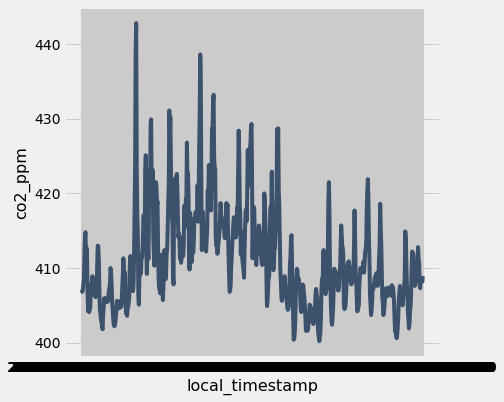

In [31]:
prev_month_emission_levels.plot('local_timestamp', 'co2_ppm')

### How does Carbon Dioxide levels compare in their PPM measurement? 

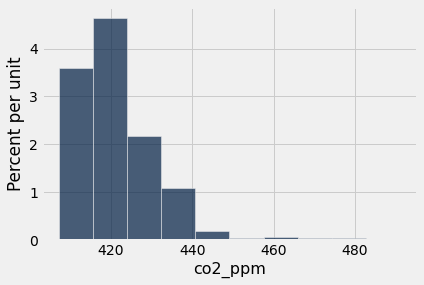

In [40]:
orange_sky_emission_levels.hist('co2_ppm')

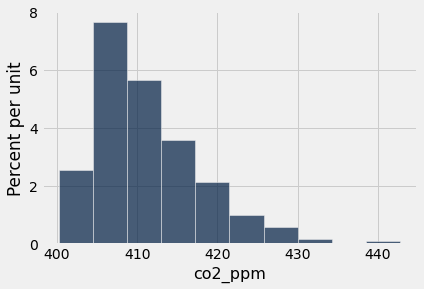

In [41]:
prev_month_emission_levels.hist('co2_ppm')